**Hip1 Clevage Prediction Models**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [3]:
asp = pd.read_csv(r"C:\Users\apkar\OneDrive\Documents\iGEM\Head\Linker design\Aspatic Protease Substrates.csv")
ser = pd.read_csv(r"C:\Users\apkar\OneDrive\Documents\iGEM\Head\Linker design\Serine_Protease_Substrates.csv")

In [5]:
asp

,Unnamed: 0,merops_id,substrate,substrate_uniprot,substrate_sequence,cleavage_site,cleavage_position,binding_window_±10
0,0,A01.001,ac-Phe-Tyr(I2),NaN,NaN,ac-Phe+Tyr(I2),NaN,NaN
1,1,A01.001,alcohol dehydrogenase,P00334,MSFTLTNKNVIFVAGLGGIGLDTSKELLKRDLKNLVILDRIENPAA...,peptide-Asn7+Lys-peptide,7.0,MSFTLTN|KNVIFVAGLG
2,2,A01.001,alcohol dehydrogenase,P00334,MSFTLTNKNVIFVAGLGGIGLDTSKELLKRDLKNLVILDRIENPAA...,peptide-Asn9+Val-peptide,9.0,MSFTLTNKN|VIFVAGLGGI
3,3,A01.001,alcohol dehydrogenase,P00334,MSFTLTNKNVIFVAGLGGIGLDTSKELLKRDLKNLVILDRIENPAA...,peptide-Phe12+Val-peptide,12.0,FTLTNKNVIF|VAGLGGIGLD
4,4,A01.001,alcohol dehydrogenase,P00334,MSFTLTNKNVIFVAGLGGIGLDTSKELLKRDLKNLVILDRIENPAA...,peptide-Gly18+Ile-peptide,18.0,NVIFVAGLGG|IGLDTSKELL
...,...,...,...,...,...,...,...,...
7951,7951,A9G.020,pro-opiomelanocortin,P01189,MPRSCCSRSGALLLALLLQASMEVRGWCLESSQCQDLTTESNLLEC...,peptide-Arg152+Glu-peptide,152.0,HFRWGKPVGK|KRRPVKVYPN
7952,7952,A9G.020,pro-opiomelanocortin,P01189,MPRSCCSRSGALLLALLLQASMEVRGWCLESSQCQDLTTESNLLEC...,peptide-Arg210+Tyr-peptide,210.0,AQADLEHSLL|VAAEKKDEGP
7953,7953,A9G.020,pro-opiomelanocortin,P01189,MPRSCCSRSGALLLALLLQASMEVRGWCLESSQCQDLTTESNLLEC...,peptide-Lys51+Tyr-peptide,51.0,NLLECIRACK|PDLSAETPMF
7954,7954,A9G.020,provasopressin,P01180,MPDATLPACFLSLLAFTSACYFQNCPRGGKRAMSDLELRQCLPCGP...,peptide-Arg31+Ala-peptide,31.0,FQNCPRGGKR|AMSDLELRQC


In [4]:
ser

,Unnamed: 0,merops_id,substrate,substrate_uniprot,substrate_sequence,cleavage_site,cleavage_position,binding_window_±10
0,0,S01.278,3-hydroxyacyl-CoA dehydrogenase type-2,Q99714,MAAACRSVKGLVAVITGGASGLGLATAERLVGQGASAVLLDLPNSG...,peptide-Cys58+Val-peptide,58.0,AQAKKLGNNC|VFAPADVTSE
1,1,S01.278,"Actin, alpha cardiac muscle 1",P68032,MCDDEETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVM...,peptide-Val19+Lys-peptide,19.0,LVCDNGSGLV|KAGFAGDDAP
2,2,S01.278,"Actin, alpha cardiac muscle 1",P68032,MCDDEETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVM...,peptide-Leu107+Thr-peptide,107.0,VAPEEHPTLL|TEAPLNPKAN
3,3,S01.278,"Actin, alpha cardiac muscle 1",P68032,MCDDEETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVM...,peptide-Thr108+Glu-peptide,108.0,APEEHPTLLT|EAPLNPKANR
4,4,S01.278,"actin, alpha skeletal muscle",P68133,MCDEDETTALVCDNGSGLVKAGFAGDDAPRAVFPSIVGRPRHQGVM...,peptide-Val19+Lys-peptide,19.0,LVCDNGSGLV|KAGFAGDDAP
...,...,...,...,...,...,...,...,...
23162,23162,S49.001,Z-Leu-OPhNO2,NaN,NaN,Z-Leu-OPhNO2,NaN,NaN
23163,23163,S49.001,Z-Phe-OPhNO2,NaN,NaN,Z-Phe-OPhNO2,NaN,NaN
23164,23164,S49.001,Z-Trp-OPhNO2,NaN,NaN,Z-Trp-OPhNO2,NaN,NaN
23165,23165,S49.001,Z-Val-NHPhNO2,NaN,NaN,Z-Val+NHPhNO2,NaN,NaN


In [6]:
asp.dropna(inplace=True)
ser.dropna(inplace=True)

In [10]:
print(asp['binding_window_±10'].nunique())
print(ser['binding_window_±10'].nunique())

4541
3758


In [23]:
final = {'Substrate':[],'Enzyme':[]}
for i in asp['binding_window_±10'].unique():
    final['Enzyme'].append('Aspartic')
    final['Substrate'].append(i)
for i in ser['binding_window_±10'].unique():
    final['Enzyme'].append('Serine')
    final['Substrate'].append(i)

In [24]:
final_data = pd.DataFrame(final)
final_data

,Substrate,Enzyme
0,MSFTLTN|KNVIFVAGLG,Aspartic
1,MSFTLTNKN|VIFVAGLGGI,Aspartic
2,FTLTNKNVIF|VAGLGGIGLD,Aspartic
3,NVIFVAGLGG|IGLDTSKELL,Aspartic
4,IFVAGLGGIG|LDTSKELLKR,Aspartic
...,...,...
8294,SKEKIGKEFK|RIVQRIKDFL,Serine
8295,KIGKEFKRIV|QRIKDFLRNL,Serine
8296,IGKEFKRIVQ|RIKDFLRNLV,Serine
8297,EFKRIVQRIK|DFLRNLVPRT,Serine


In [25]:
import pandas as pd

df = final_data.copy()

# Clean substrate sequence
df['Substrate'] = (
    df['Substrate']
    .astype(str)
    .str.strip()
    .str.upper()
)

# Standard amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Amino acid classification
hydrophobic = set("AVILMFWY")
hydrophilic = set("DEKRHNQSTCPG")


# =========================================================
# 1. Amino acid counts
# =========================================================

for aa in amino_acids:
    df[f'AA_count_{aa}'] = df['Substrate'].apply(
        lambda x, aa=aa: x.replace('|', '').count(aa)
    )


# =========================================================
# 2. Total amino acid count
# =========================================================

df['AA_total'] = df['Substrate'].apply(
    lambda x: sum(x.replace('|', '').count(aa) for aa in amino_acids)
)


# =========================================================
# 3. Amino acid percentages
# =========================================================

for aa in amino_acids:
    df[f'AA_pct_{aa}'] = (
        df[f'AA_count_{aa}'] /
        df['AA_total'].replace(0, pd.NA)
    ) * 100


# =========================================================
# 4. Hydrophobic and hydrophilic counts
# =========================================================

df['Hydrophobic_count'] = df['Substrate'].apply(
    lambda x: sum(
        x.replace('|', '').count(aa)
        for aa in hydrophobic
    )
)

df['Hydrophilic_count'] = df['Substrate'].apply(
    lambda x: sum(
        x.replace('|', '').count(aa)
        for aa in hydrophilic
    )
)


# =========================================================
# 5. Hydrophobic and hydrophilic percentages
# =========================================================

df['Hydrophobic_pct'] = (
    df['Hydrophobic_count'] /
    df['AA_total'].replace(0, pd.NA)
) * 100

df['Hydrophilic_pct'] = (
    df['Hydrophilic_count'] /
    df['AA_total'].replace(0, pd.NA)
) * 100


# =========================================================
# 6. Extract 2 AA before and 2 AA after "|"
#
# Example:
#
# ABCD|EFGH
#   ↑↑ ↑↑
#   2  | 2
#
# Result:
# CD|EF
# =========================================================

def get_flanking_aas(sequence):

    if '|' not in sequence:
        return 'X', 'X', 'X', 'X'

    left, right = sequence.split('|', 1)

    left = left[-2:]
    right = right[:2]

    # Handle sequences with <2 AA on either side
    left = left.rjust(2, 'X')
    right = right.ljust(2, 'X')

    return left[0], left[1], right[0], right[1]


df[
    ['AA_minus2', 'AA_minus1', 'AA_plus1', 'AA_plus2']
] = df['Substrate'].apply(
    get_flanking_aas
).apply(pd.Series)


# =========================================================
# 7. Create OHE for the 4 positions around "|"
# =========================================================

positions = [
    'AA_minus2',
    'AA_minus1',
    'AA_plus1',
    'AA_plus2'
]

for position in positions:

    for aa in amino_acids:

        df[f'OHE_{position}_{aa}'] = (
            df[position] == aa
        ).astype(int)


# =========================================================
# 8. Create the 4-AA motif
# =========================================================

df['Flanking_AA'] = (
    df['AA_minus2'] +
    df['AA_minus1'] +
    '|' +
    df['AA_plus1'] +
    df['AA_plus2']
)


# =========================================================
# 9. Update final_dataset
# =========================================================

final_dataset = df

print(final_dataset.head())
print("Shape:", final_dataset.shape)


               Substrate    Enzyme  AA_count_A  AA_count_C  AA_count_D  \
0     MSFTLTN|KNVIFVAGLG  Aspartic           1           0           0   
1   MSFTLTNKN|VIFVAGLGGI  Aspartic           1           0           0   
2  FTLTNKNVIF|VAGLGGIGLD  Aspartic           1           0           1   
3  NVIFVAGLGG|IGLDTSKELL  Aspartic           1           0           1   
4  IFVAGLGGIG|LDTSKELLKR  Aspartic           1           0           1   

   AA_count_E  AA_count_F  AA_count_G  AA_count_H  AA_count_I  ...  \
0           0           2           2           0           1  ...   
1           0           2           3           0           2  ...   
2           0           2           4           0           2  ...   
3           1           1           4           0           2  ...   
4           1           1           4           0           2  ...   

   OHE_AA_plus2_N  OHE_AA_plus2_P  OHE_AA_plus2_Q  OHE_AA_plus2_R  \
0               1               0               0               0

C:\Users\apkar\AppData\Local\Temp\ipykernel_2800\70948123.py:137: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'OHE_{position}_{aa}'] = (
C:\Users\apkar\AppData\Local\Temp\ipykernel_2800\70948123.py:137: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'OHE_{position}_{aa}'] = (
C:\Users\apkar\AppData\Local\Temp\ipykernel_2800\70948123.py:137: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at onc

In [26]:
df

,Substrate,Enzyme,AA_count_A,AA_count_C,AA_count_D,AA_count_E,AA_count_F,AA_count_G,AA_count_H,AA_count_I,...,OHE_AA_plus2_N,OHE_AA_plus2_P,OHE_AA_plus2_Q,OHE_AA_plus2_R,OHE_AA_plus2_S,OHE_AA_plus2_T,OHE_AA_plus2_V,OHE_AA_plus2_W,OHE_AA_plus2_Y,Flanking_AA
0,MSFTLTN|KNVIFVAGLG,Aspartic,1,0,0,0,2,2,0,1,...,1,0,0,0,0,0,0,0,0,TN|KN
1,MSFTLTNKN|VIFVAGLGGI,Aspartic,1,0,0,0,2,3,0,2,...,0,0,0,0,0,0,0,0,0,KN|VI
2,FTLTNKNVIF|VAGLGGIGLD,Aspartic,1,0,1,0,2,4,0,2,...,0,0,0,0,0,0,0,0,0,IF|VA
3,NVIFVAGLGG|IGLDTSKELL,Aspartic,1,0,1,1,1,4,0,2,...,0,0,0,0,0,0,0,0,0,GG|IG
4,IFVAGLGGIG|LDTSKELLKR,Aspartic,1,0,1,1,1,4,0,2,...,0,0,0,0,0,0,0,0,0,IG|LD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8294,SKEKIGKEFK|RIVQRIKDFL,Serine,0,0,1,2,2,1,0,3,...,0,0,0,0,0,0,0,0,0,FK|RI
8295,KIGKEFKRIV|QRIKDFLRNL,Serine,0,0,1,1,2,1,0,3,...,0,0,0,1,0,0,0,0,0,IV|QR
8296,IGKEFKRIVQ|RIKDFLRNLV,Serine,0,0,1,1,2,1,0,3,...,0,0,0,0,0,0,0,0,0,VQ|RI
8297,EFKRIVQRIK|DFLRNLVPRT,Serine,0,0,1,1,2,0,0,2,...,0,0,0,0,0,0,0,0,0,IK|DF


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)


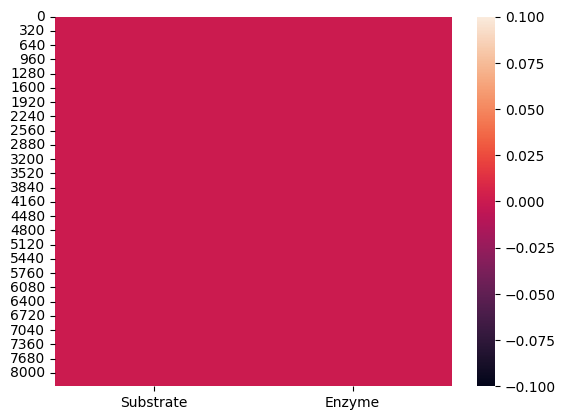

In [31]:
import seaborn as sns
sns.heatmap(final_data.isnull())
final_data.dropna(inplace= True)

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# ============================================================
# Prepare X and y
# ============================================================

# Target
y = final_dataset['Enzyme'].copy()

# Encode the two enzyme classes
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Enzyme classes:")
print(label_encoder.classes_)

# Features
X = final_dataset.drop(columns=['Enzyme']).copy()

# Keep only numerical features
X = X.select_dtypes(include=[np.number])

# Convert pandas NA / inf values to numpy NaN
X = X.replace([np.inf, -np.inf], np.nan)

print("\nNumber of features:", X.shape[1])
print("Number of samples:", X.shape[0])
print("Missing values:", X.isna().sum().sum())

# ============================================================
# 60% Training / 40% Testing
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

# ============================================================
# Imputation
# Fit ONLY on training data
# ============================================================

imputer = SimpleImputer(strategy='median')

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nMissing values after imputation:",
      np.isnan(X_train_imputed).sum() +
      np.isnan(X_test_imputed).sum())


Enzyme classes:
['Aspartic' 'Serine']

Number of features: 103
Number of samples: 8299
Missing values: 0

Training samples: 4979
Testing samples: 3320

Missing values after imputation: 0


LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Aspartic       0.82      0.84      0.83      1817
      Serine       0.80      0.77      0.79      1503

    accuracy                           0.81      3320
   macro avg       0.81      0.81      0.81      3320
weighted avg       0.81      0.81      0.81      3320



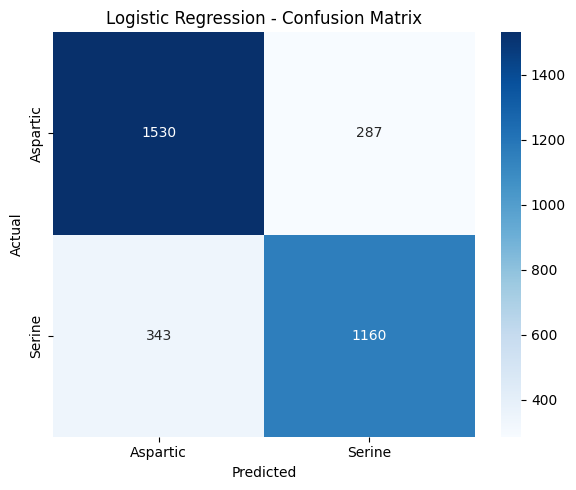

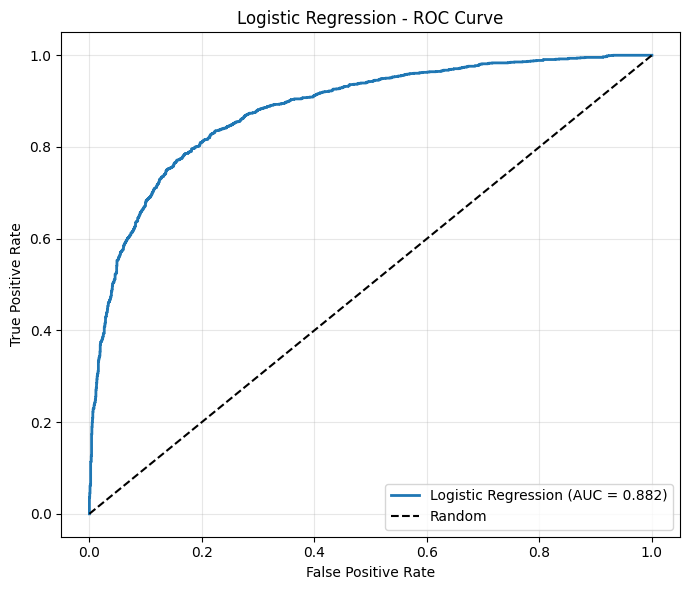

ROC-AUC: 0.8823


In [35]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Scale
# ------------------------------------------------------------

scaler_lr = StandardScaler()

X_train_scaled = scaler_lr.fit_transform(X_train_imputed)
X_test_scaled = scaler_lr.transform(X_test_imputed)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("LOGISTIC REGRESSION")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC + AUC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


SUPPORT VECTOR MACHINE
              precision    recall  f1-score   support

    Aspartic       0.82      0.87      0.84      1817
      Serine       0.83      0.77      0.80      1503

    accuracy                           0.82      3320
   macro avg       0.82      0.82      0.82      3320
weighted avg       0.82      0.82      0.82      3320



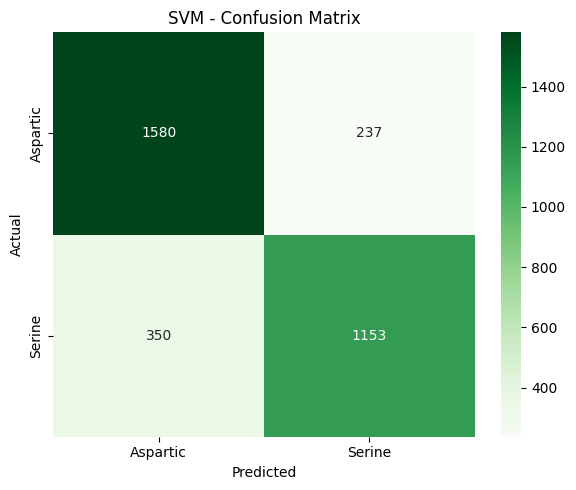

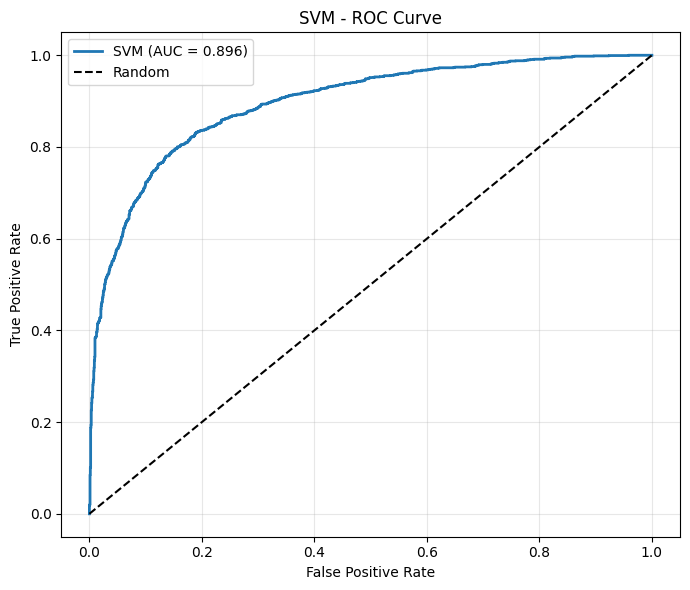

ROC-AUC: 0.8956


In [36]:
# ============================================================
# SUPPORT VECTOR MACHINE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Scale
# ------------------------------------------------------------

scaler_svm = StandardScaler()

X_train_scaled = scaler_svm.fit_transform(X_train_imputed)
X_test_scaled = scaler_svm.transform(X_test_imputed)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = svm_model.predict(X_test_scaled)

# Decision score for ROC
y_score = svm_model.decision_function(X_test_scaled)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("SUPPORT VECTOR MACHINE")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC + AUC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(y_test, y_score)

auc_score = roc_auc_score(
    y_test,
    y_score
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


DECISION TREE
              precision    recall  f1-score   support

    Aspartic       0.77      0.74      0.76      1817
      Serine       0.70      0.73      0.72      1503

    accuracy                           0.74      3320
   macro avg       0.74      0.74      0.74      3320
weighted avg       0.74      0.74      0.74      3320



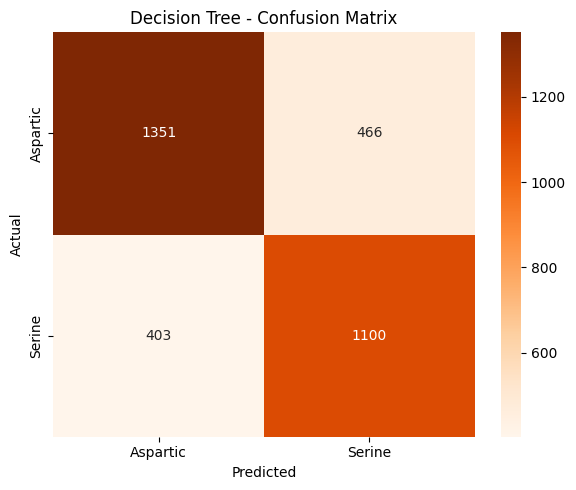

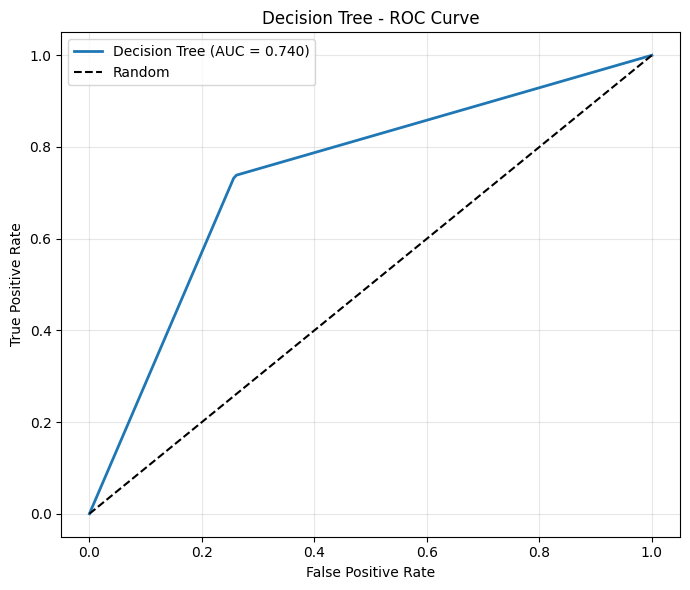

ROC-AUC: 0.7395


In [37]:
# ============================================================
# DECISION TREE
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

dt_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_model.fit(
    X_train_imputed,
    y_train
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = dt_model.predict(X_test_imputed)

y_prob = dt_model.predict_proba(
    X_test_imputed
)[:, 1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("DECISION TREE")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC + AUC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Decision Tree (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


K-NEAREST NEIGHBORS
              precision    recall  f1-score   support

    Aspartic       0.79      0.78      0.79      1817
      Serine       0.74      0.75      0.75      1503

    accuracy                           0.77      3320
   macro avg       0.77      0.77      0.77      3320
weighted avg       0.77      0.77      0.77      3320



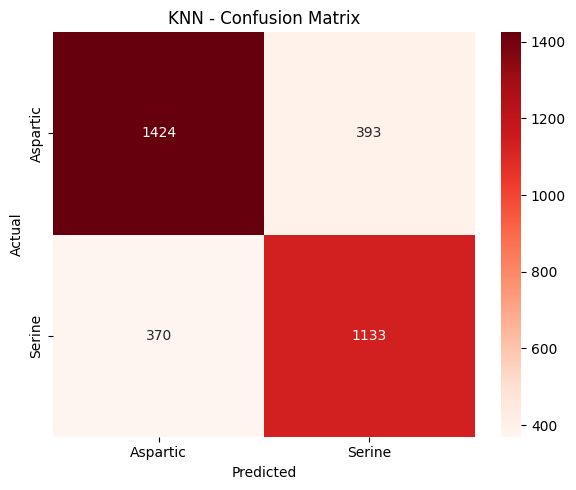

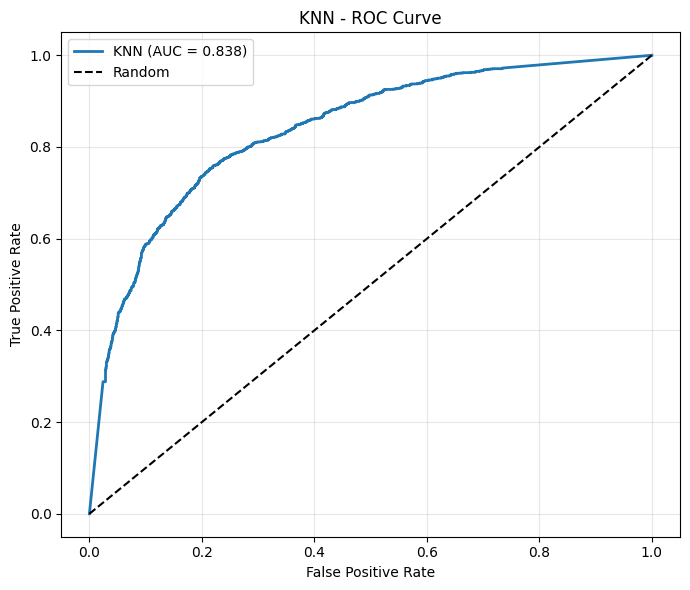

ROC-AUC: 0.8376


In [38]:
# ============================================================
# K-NEAREST NEIGHBORS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Scale
# ------------------------------------------------------------

scaler_knn = StandardScaler()

X_train_scaled = scaler_knn.fit_transform(
    X_train_imputed
)

X_test_scaled = scaler_knn.transform(
    X_test_imputed
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    n_jobs=-1
)

knn_model.fit(
    X_train_scaled,
    y_train
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = knn_model.predict(
    X_test_scaled
)

y_prob = knn_model.predict_proba(
    X_test_scaled
)[:, 1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("K-NEAREST NEIGHBORS")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC + AUC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"KNN (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


RANDOM FOREST
              precision    recall  f1-score   support

    Aspartic       0.82      0.86      0.84      1817
      Serine       0.82      0.77      0.79      1503

    accuracy                           0.82      3320
   macro avg       0.82      0.81      0.82      3320
weighted avg       0.82      0.82      0.82      3320



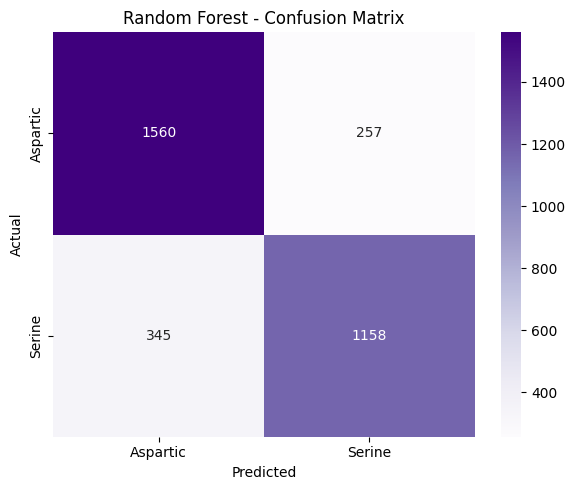

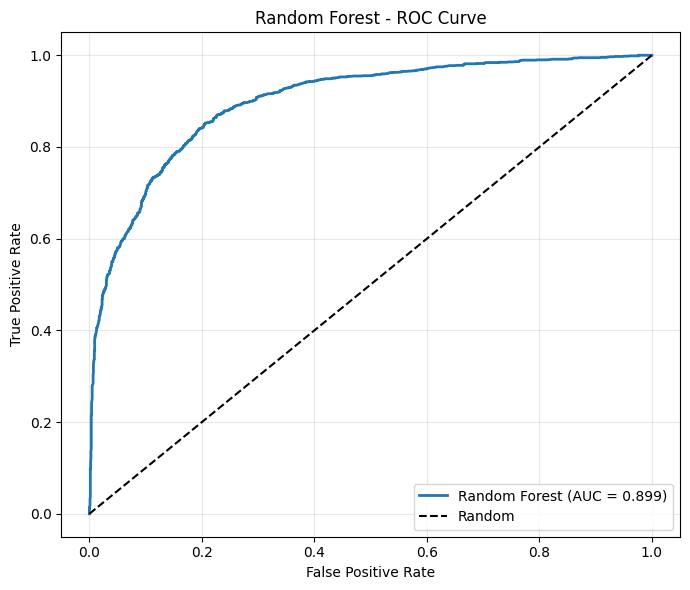

ROC-AUC: 0.8991


In [39]:
# ============================================================
# RANDOM FOREST
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_imputed,
    y_train
)

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

y_pred = rf_model.predict(X_test_imputed)

y_prob = rf_model.predict_proba(
    X_test_imputed
)[:, 1]

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("RANDOM FOREST")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# ROC + AUC
# ------------------------------------------------------------

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {auc_score:.4f}")


Number of features: 103

Calculating SVM permutation importance...
Calculating KNN permutation importance...


TOP 10 FEATURES - LOGISTIC REGRESSION
        Feature  Importance
OHE_AA_minus1_F    0.826195
OHE_AA_minus1_D    0.819627
OHE_AA_minus1_R    0.481579
OHE_AA_minus2_P    0.465923
OHE_AA_minus1_Y    0.401608
 OHE_AA_plus1_S    0.318916
     AA_count_H    0.294716
OHE_AA_minus1_L    0.261517
OHE_AA_minus2_I    0.245781
 OHE_AA_plus1_F    0.237022


TOP 10 FEATURES - SVM
        Feature  Importance
OHE_AA_minus1_D    0.036556
OHE_AA_minus1_R    0.019762
OHE_AA_minus2_P    0.015445
OHE_AA_minus1_F    0.014983
 OHE_AA_plus1_S    0.006449
     AA_count_E    0.005601
OHE_AA_minus1_L    0.005531
     AA_count_A    0.004997
     AA_count_H    0.004437
OHE_AA_minus2_I    0.003171


TOP 10 FEATURES - DECISION TREE
          Feature  Importance
  OHE_AA_minus1_D    0.153982
  OHE_AA_minus1_R    0.093496
  OHE_AA_minus2_P    0.040112
       AA_count_A    0.030826
       AA_count_E    0.0307

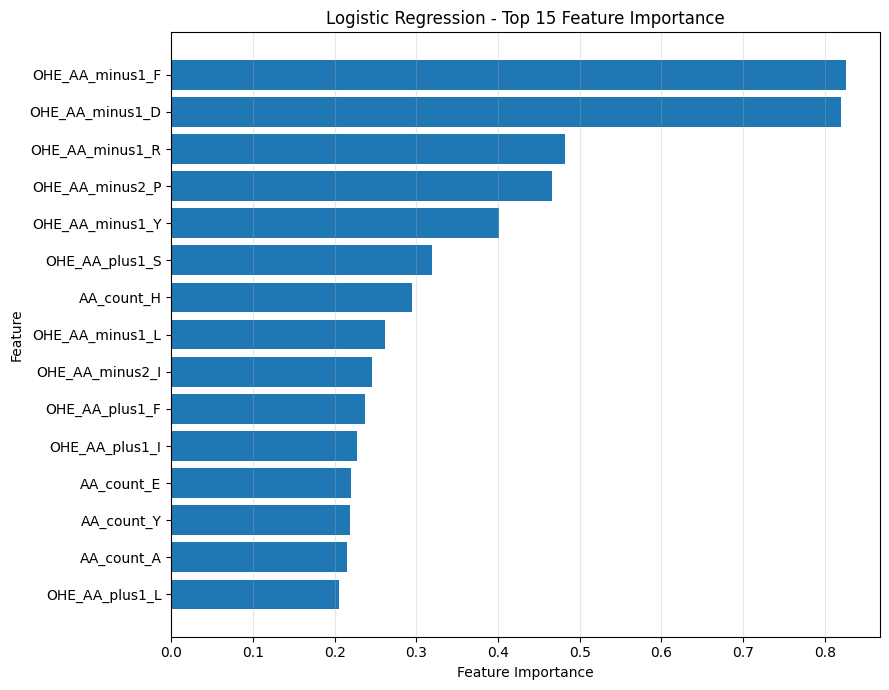

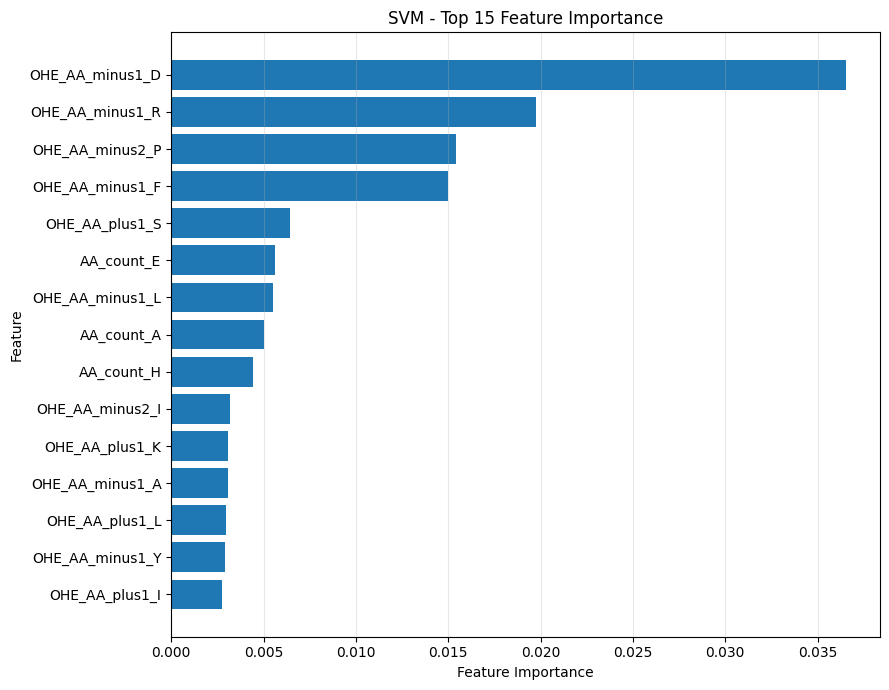

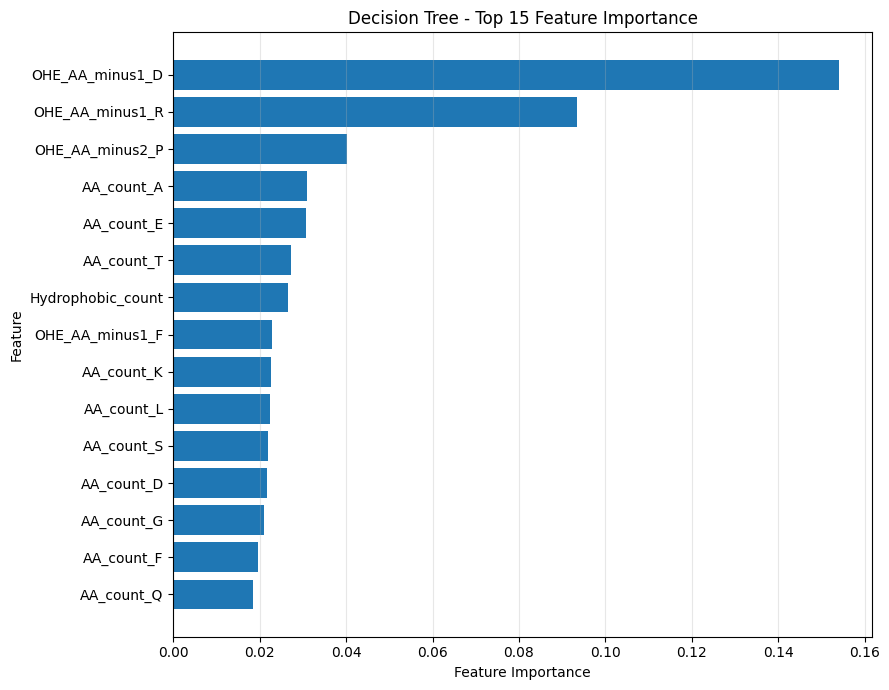

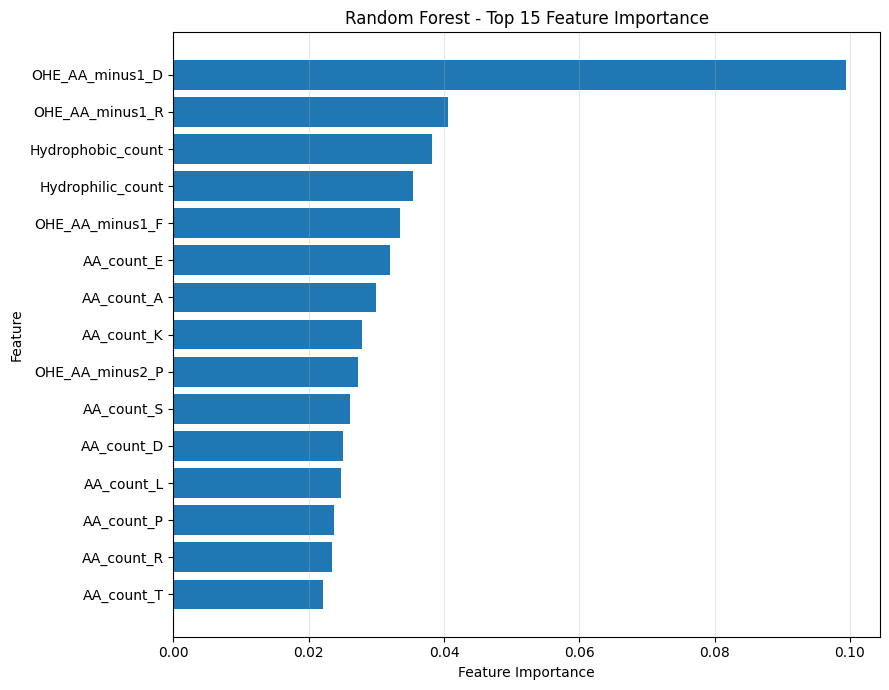

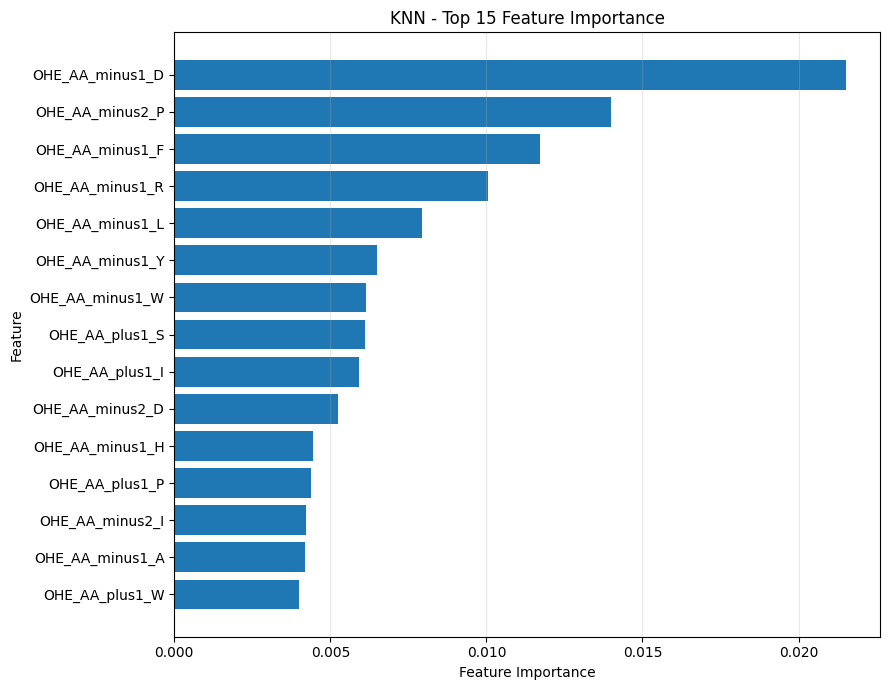



TOP 3 FEATURES FOR EACH MODEL
              Model  Rank           Feature  Importance
Logistic Regression     1   OHE_AA_minus1_F    0.826195
Logistic Regression     2   OHE_AA_minus1_D    0.819627
Logistic Regression     3   OHE_AA_minus1_R    0.481579
                SVM     1   OHE_AA_minus1_D    0.036556
                SVM     2   OHE_AA_minus1_R    0.019762
                SVM     3   OHE_AA_minus2_P    0.015445
      Decision Tree     1   OHE_AA_minus1_D    0.153982
      Decision Tree     2   OHE_AA_minus1_R    0.093496
      Decision Tree     3   OHE_AA_minus2_P    0.040112
      Random Forest     1   OHE_AA_minus1_D    0.099471
      Random Forest     2   OHE_AA_minus1_R    0.040656
      Random Forest     3 Hydrophobic_count    0.038214
                KNN     1   OHE_AA_minus1_D    0.021533
                KNN     2   OHE_AA_minus2_P    0.014005
                KNN     3   OHE_AA_minus1_F    0.011707


TOP 3 FEATURE TABLE


,Top 1 Feature,Top 2 Feature,Top 3 Feature
Model,,,
Decision Tree,OHE_AA_minus1_D,OHE_AA_minus1_R,OHE_AA_minus2_P
KNN,OHE_AA_minus1_D,OHE_AA_minus2_P,OHE_AA_minus1_F
Logistic Regression,OHE_AA_minus1_F,OHE_AA_minus1_D,OHE_AA_minus1_R
Random Forest,OHE_AA_minus1_D,OHE_AA_minus1_R,Hydrophobic_count
SVM,OHE_AA_minus1_D,OHE_AA_minus1_R,OHE_AA_minus2_P


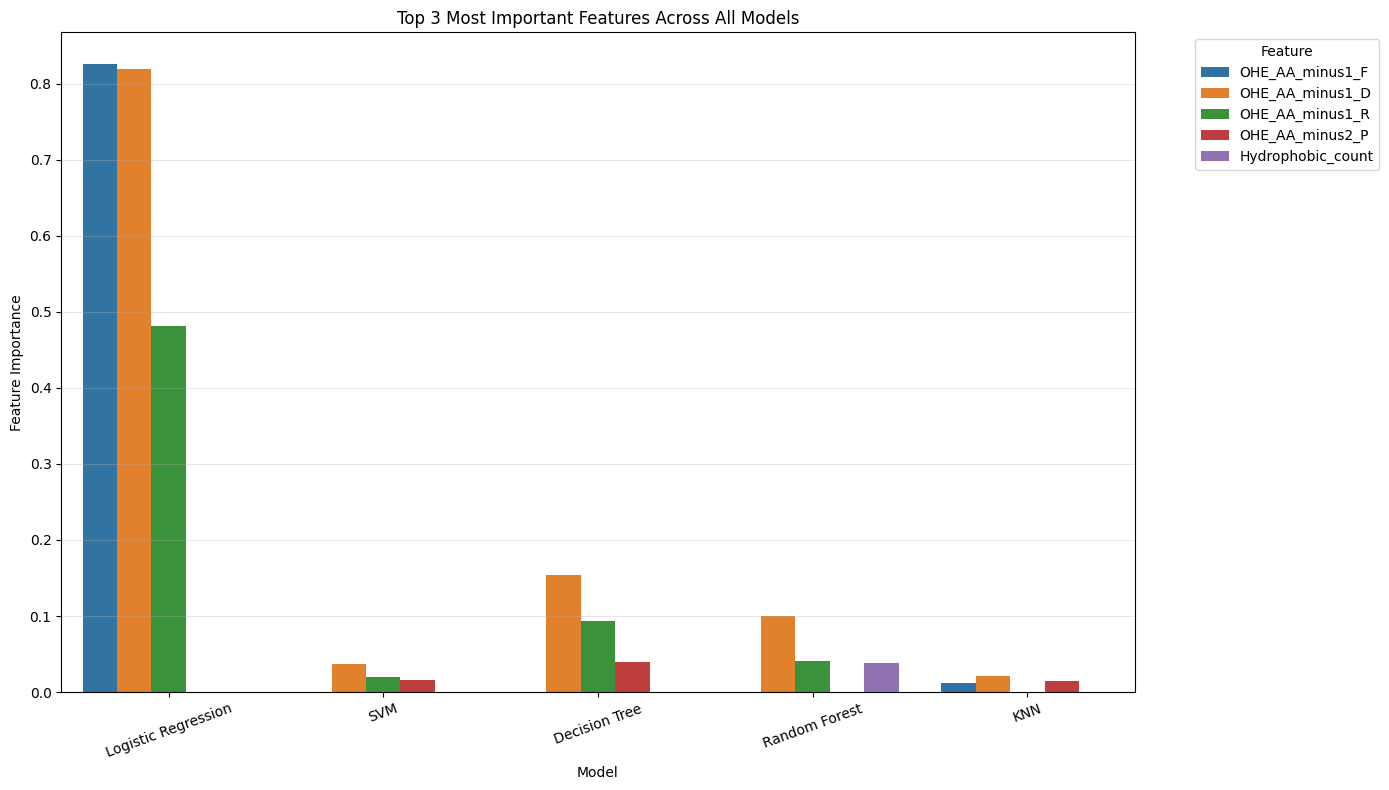

Feature                                      \
Rank                               1                2                  3   
Model                                                                      
Decision Tree        OHE_AA_minus1_D  OHE_AA_minus1_R    OHE_AA_minus2_P   
KNN                  OHE_AA_minus1_D  OHE_AA_minus2_P    OHE_AA_minus1_F   
Logistic Regression  OHE_AA_minus1_F  OHE_AA_minus1_D    OHE_AA_minus1_R   
Random Forest        OHE_AA_minus1_D  OHE_AA_minus1_R  Hydrophobic_count   
SVM                  OHE_AA_minus1_D  OHE_AA_minus1_R    OHE_AA_minus2_P   

                    Importance                      
Rank                         1         2         3  
Model                                               
Decision Tree         0.153982  0.093496  0.040112  
KNN                   0.021533  0.014005  0.011707  
Logistic Regression   0.826195  0.819627  0.481579  
Random Forest         0.099471  0.040656  0.038214  
SVM                   0.036556  0.019762  0.015445


Feature importance analysis completed.


In [40]:
# ============================================================
# FEATURE IMPORTANCE FOR ALL 5 MODELS
# ============================================================
#
# Models assumed to already exist:
#
# lr_model
# svm_model
# dt_model
# rf_model
# knn_model
#
# And:
#
# X_train, X_test
# X_train_imputed, X_test_imputed
# X_train_scaled, X_test_scaled
# y_train, y_test
#
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.inspection import permutation_importance


# ============================================================
# 1. Get feature names
# ============================================================

feature_names = X.columns.tolist()

print("Number of features:", len(feature_names))


# ============================================================
# 2. Logistic Regression Feature Importance
# ============================================================

lr_importance = np.abs(
    lr_model.coef_[0]
)

lr_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lr_importance
})

lr_importance_df = lr_importance_df.sort_values(
    by='Importance',
    ascending=False
)


# ============================================================
# 3. Decision Tree Feature Importance
# ============================================================

dt_importance = dt_model.feature_importances_

dt_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_importance
})

dt_importance_df = dt_importance_df.sort_values(
    by='Importance',
    ascending=False
)


# ============================================================
# 4. Random Forest Feature Importance
# ============================================================

rf_importance = rf_model.feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
})

rf_importance_df = rf_importance_df.sort_values(
    by='Importance',
    ascending=False
)


# ============================================================
# 5. SVM Permutation Importance
# ============================================================

print("\nCalculating SVM permutation importance...")

svm_perm = permutation_importance(
    svm_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

svm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': svm_perm.importances_mean
})

svm_importance_df = svm_importance_df.sort_values(
    by='Importance',
    ascending=False
)


# ============================================================
# 6. KNN Permutation Importance
# ============================================================

print("Calculating KNN permutation importance...")

knn_perm = permutation_importance(
    knn_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

knn_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': knn_perm.importances_mean
})

knn_importance_df = knn_importance_df.sort_values(
    by='Importance',
    ascending=False
)


# ============================================================
# 7. Display TOP 10 features for each model
# ============================================================

print("\n")
print("=" * 70)
print("TOP 10 FEATURES - LOGISTIC REGRESSION")
print("=" * 70)

print(lr_importance_df.head(10).to_string(index=False))


print("\n")
print("=" * 70)
print("TOP 10 FEATURES - SVM")
print("=" * 70)

print(svm_importance_df.head(10).to_string(index=False))


print("\n")
print("=" * 70)
print("TOP 10 FEATURES - DECISION TREE")
print("=" * 70)

print(dt_importance_df.head(10).to_string(index=False))


print("\n")
print("=" * 70)
print("TOP 10 FEATURES - RANDOM FOREST")
print("=" * 70)

print(rf_importance_df.head(10).to_string(index=False))


print("\n")
print("=" * 70)
print("TOP 10 FEATURES - KNN")
print("=" * 70)

print(knn_importance_df.head(10).to_string(index=False))


# ============================================================
# 8. Plot feature importance for EACH model
# ============================================================

importance_dict = {
    'Logistic Regression': lr_importance_df,
    'SVM': svm_importance_df,
    'Decision Tree': dt_importance_df,
    'Random Forest': rf_importance_df,
    'KNN': knn_importance_df
}


for model_name, importance_df in importance_dict.items():

    top_features = importance_df.head(15).copy()

    # Reverse so highest appears at top
    top_features = top_features.iloc[::-1]

    plt.figure(figsize=(9, 7))

    plt.barh(
        top_features['Feature'],
        top_features['Importance']
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title(
        f"{model_name} - Top 15 Feature Importance"
    )

    plt.grid(
        axis='x',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. Get TOP 3 features from every model
# ============================================================

top3_data = []

for model_name, importance_df in importance_dict.items():

    top3 = importance_df.head(3)

    for rank, (_, row) in enumerate(
        top3.iterrows(),
        start=1
    ):

        top3_data.append({
            'Model': model_name,
            'Rank': rank,
            'Feature': row['Feature'],
            'Importance': row['Importance']
        })


# ============================================================
# 10. Create TOP 3 table
# ============================================================

top3_table = pd.DataFrame(top3_data)

print("\n")
print("=" * 70)
print("TOP 3 FEATURES FOR EACH MODEL")
print("=" * 70)

print(
    top3_table.to_string(index=False)
)


# ============================================================
# 11. Create a cleaner pivot table
# ============================================================

top3_pivot = top3_table.pivot(
    index='Model',
    columns='Rank',
    values='Feature'
)

top3_pivot.columns = [
    'Top 1 Feature',
    'Top 2 Feature',
    'Top 3 Feature'
]

print("\n")
print("=" * 70)
print("TOP 3 FEATURE TABLE")
print("=" * 70)

display(top3_pivot)


# ============================================================
# 12. Combined bar graph of TOP 3 features
# ============================================================

plt.figure(figsize=(14, 8))

sns.barplot(
    data=top3_table,
    x='Model',
    y='Importance',
    hue='Feature'
)

plt.xlabel("Model")
plt.ylabel("Feature Importance")
plt.title(
    "Top 3 Most Important Features Across All Models"
)

plt.xticks(rotation=20)

plt.legend(
    title='Feature',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 13. Optional: Combined TOP 3 table with importance values
# ============================================================

top3_with_values = top3_table.pivot(
    index='Model',
    columns='Rank',
    values=['Feature', 'Importance']
)

display(top3_with_values)


print("\nFeature importance analysis completed.")


MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall
0,Logistic Regression,81.02,80.17,77.18
1,SVM,82.32,82.95,76.71
2,Decision Tree,73.83,70.24,73.19
3,Random Forest,81.87,81.84,77.05
4,KNN,77.02,74.25,75.38


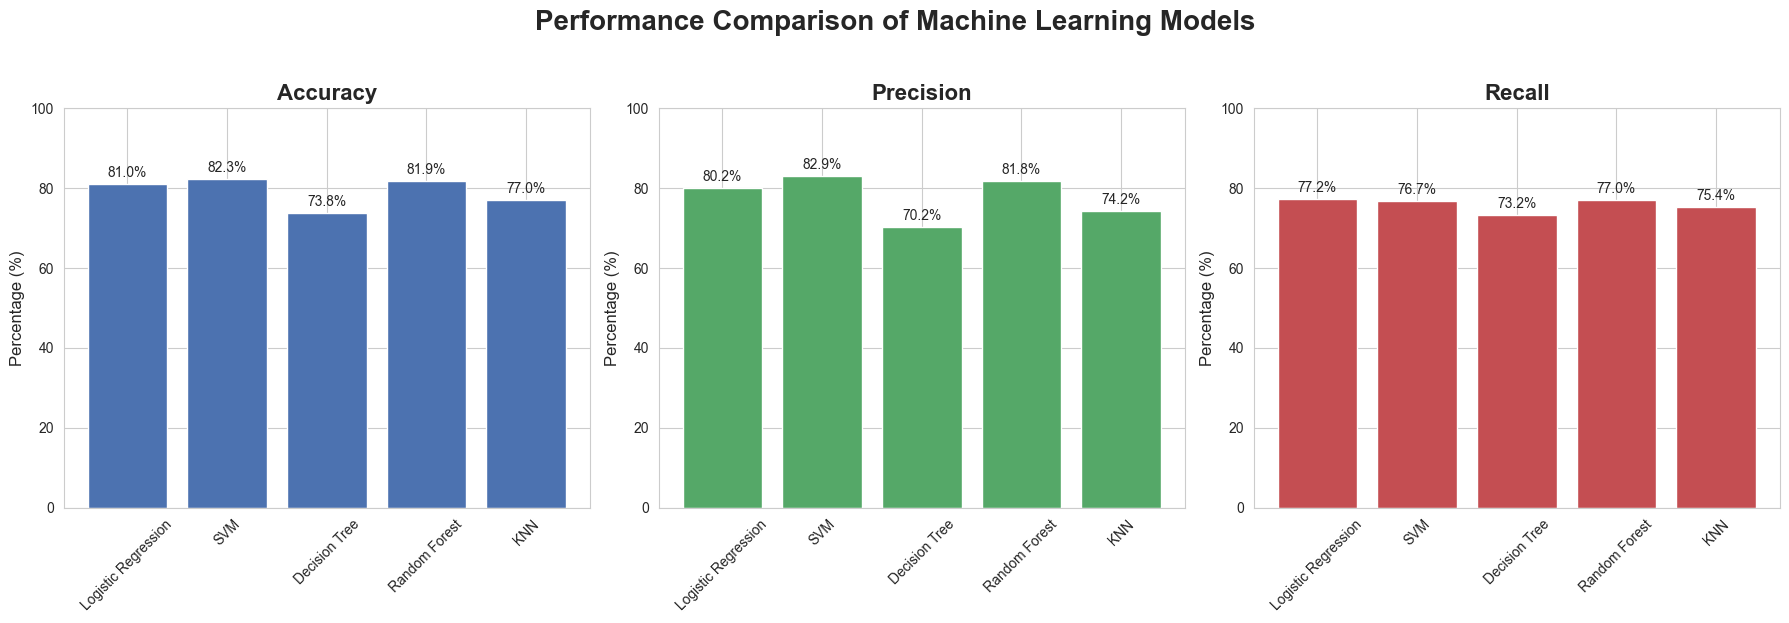

In [42]:
# ============================================================
# ACCURACY, PRECISION & RECALL FOR ALL MODELS
# 3 BAR PLOTS IN ONE FIGURE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# ============================================================
# 1. Generate predictions from all models
# ============================================================

# Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)

# SVM
y_pred_svm = svm_model.predict(X_test_scaled)

# Decision Tree
y_pred_dt = dt_model.predict(X_test_imputed)

# Random Forest
y_pred_rf = rf_model.predict(X_test_imputed)

# KNN
y_pred_knn = knn_model.predict(X_test_scaled)


# ============================================================
# 2. Calculate metrics
# ============================================================

models = [
    'Logistic Regression',
    'SVM',
    'Decision Tree',
    'Random Forest',
    'KNN'
]

predictions = [
    y_pred_lr,
    y_pred_svm,
    y_pred_dt,
    y_pred_rf,
    y_pred_knn
]

accuracy = []
precision = []
recall = []

for y_pred in predictions:

    accuracy.append(
        accuracy_score(y_test, y_pred)
    )

    precision.append(
        precision_score(
            y_test,
            y_pred,
            average='binary'
        )
    )

    recall.append(
        recall_score(
            y_test,
            y_pred,
            average='binary'
        )
    )


# ============================================================
# 3. Create results table
# ============================================================

results = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall
})

# Convert to percentage
results['Accuracy'] *= 100
results['Precision'] *= 100
results['Recall'] *= 100

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

display(
    results.round(2)
)


# ============================================================
# 4. Plot 3 sections
# ============================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)


# ------------------------------------------------------------
# Accuracy
# ------------------------------------------------------------

bars1 = axes[0].bar(
    results['Model'],
    results['Accuracy'],
    color='#4C72B0'
)

axes[0].set_title(
    'Accuracy',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel(
    'Percentage (%)',
    fontsize=12
)

axes[0].set_ylim(0, 100)

axes[0].tick_params(
    axis='x',
    rotation=45
)

# Add values on bars
for bar in bars1:

    height = bar.get_height()

    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


# ------------------------------------------------------------
# Precision
# ------------------------------------------------------------

bars2 = axes[1].bar(
    results['Model'],
    results['Precision'],
    color='#55A868'
)

axes[1].set_title(
    'Precision',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_ylabel(
    'Percentage (%)',
    fontsize=12
)

axes[1].set_ylim(0, 100)

axes[1].tick_params(
    axis='x',
    rotation=45
)

# Add values on bars
for bar in bars2:

    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


# ------------------------------------------------------------
# Recall
# ------------------------------------------------------------

bars3 = axes[2].bar(
    results['Model'],
    results['Recall'],
    color='#C44E52'
)

axes[2].set_title(
    'Recall',
    fontsize=16,
    fontweight='bold'
)

axes[2].set_ylabel(
    'Percentage (%)',
    fontsize=12
)

axes[2].set_ylim(0, 100)

axes[2].tick_params(
    axis='x',
    rotation=45
)

# Add values on bars
for bar in bars3:

    height = bar.get_height()

    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


# ============================================================
# 5. Overall figure formatting
# ============================================================

fig.suptitle(
    'Performance Comparison of Machine Learning Models',
    fontsize=20,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.show()


MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall
0,Logistic Regression,81.02,80.17,77.18
1,SVM,82.32,82.95,76.71
2,Decision Tree,73.83,70.24,73.19
3,Random Forest,81.87,81.84,77.05
4,KNN,77.02,74.25,75.38


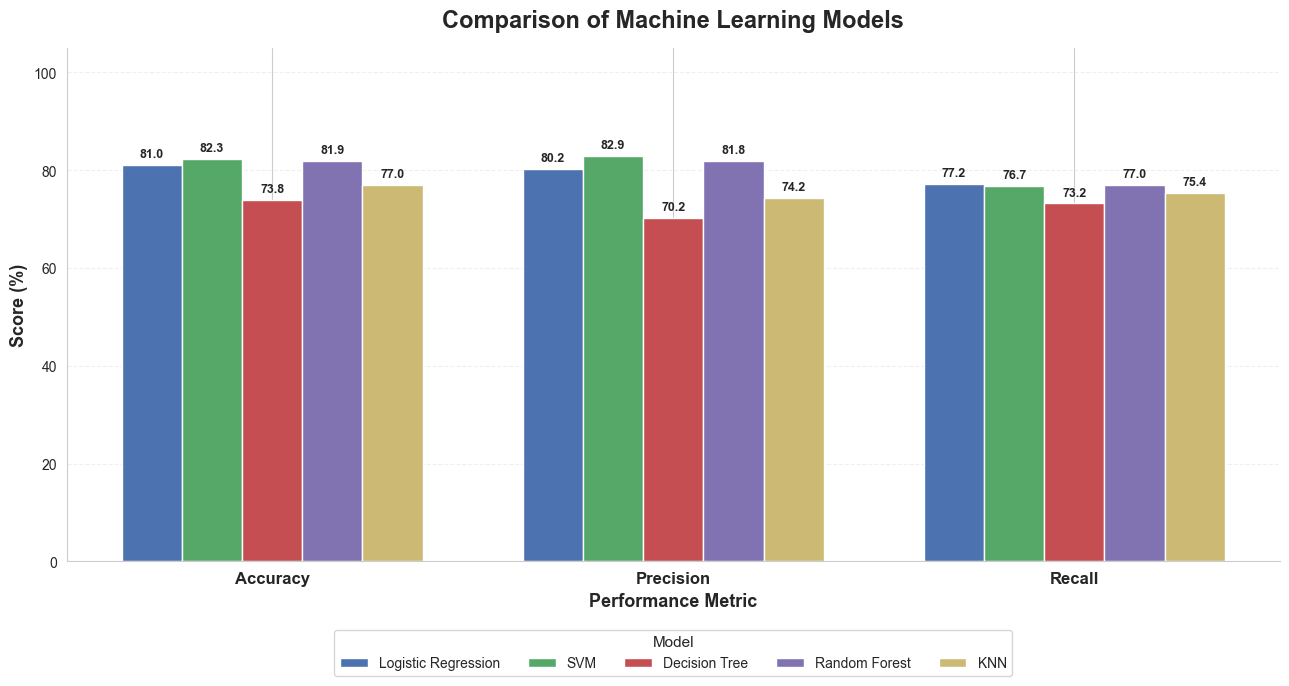

In [43]:
# ============================================================
# SINGLE GROUPED BAR PLOT
# Accuracy vs Precision vs Recall
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score
)

# ============================================================
# 1. Predictions from all models
# ============================================================

y_pred_lr = lr_model.predict(X_test_scaled)

y_pred_svm = svm_model.predict(X_test_scaled)

y_pred_dt = dt_model.predict(X_test_imputed)

y_pred_rf = rf_model.predict(X_test_imputed)

y_pred_knn = knn_model.predict(X_test_scaled)


# ============================================================
# 2. Model names and predictions
# ============================================================

models = {
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn
}


# ============================================================
# 3. Calculate metrics
# ============================================================

results = []

for model_name, y_pred in models.items():

    results.append({
        'Model': model_name,

        'Accuracy': accuracy_score(
            y_test,
            y_pred
        ) * 100,

        'Precision': precision_score(
            y_test,
            y_pred,
            average='binary'
        ) * 100,

        'Recall': recall_score(
            y_test,
            y_pred,
            average='binary'
        ) * 100
    })


results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

display(
    results_df.round(2)
)


# ============================================================
# 4. Prepare grouped bar plot
# ============================================================

metrics = [
    'Accuracy',
    'Precision',
    'Recall'
]

model_names = results_df['Model'].tolist()

x = np.arange(len(metrics))

# Width of each individual bar
width = 0.15

# Colors for the 5 models
colors = [
    '#4C72B0',  # Blue
    '#55A868',  # Green
    '#C44E52',  # Red
    '#8172B2',  # Purple
    '#CCB974'   # Yellow
]


# ============================================================
# 5. Create figure
# ============================================================

fig, ax = plt.subplots(
    figsize=(13, 7)
)


# ============================================================
# 6. Plot each model
# ============================================================

for i, model in enumerate(model_names):

    values = results_df.loc[
        results_df['Model'] == model,
        metrics
    ].values.flatten()

    bars = ax.bar(
        x + (i - 2) * width,
        values,
        width,
        label=model,
        color=colors[i]
    )

    # --------------------------------------------------------
    # Add value on top of every bar
    # --------------------------------------------------------

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f'{height:.1f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )


# ============================================================
# 7. Formatting
# ============================================================

ax.set_xlabel(
    'Performance Metric',
    fontsize=13,
    fontweight='bold'
)

ax.set_ylabel(
    'Score (%)',
    fontsize=13,
    fontweight='bold'
)

ax.set_title(
    'Comparison of Machine Learning Models',
    fontsize=17,
    fontweight='bold',
    pad=15
)

ax.set_xticks(x)

ax.set_xticklabels(
    metrics,
    fontsize=12,
    fontweight='bold'
)

ax.set_ylim(
    0,
    105
)

ax.legend(
    title='Model',
    fontsize=10,
    title_fontsize=11,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=5
)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()


In [41]:
import joblib
import os

# ============================================================
# Create folder
# ============================================================

model_dir = "saved_models"

os.makedirs(model_dir, exist_ok=True)


# ============================================================
# Save models
# ============================================================

joblib.dump(
    lr_model,
    os.path.join(model_dir, "logistic_regression.pkl")
)

joblib.dump(
    svm_model,
    os.path.join(model_dir, "svm.pkl")
)

joblib.dump(
    dt_model,
    os.path.join(model_dir, "decision_tree.pkl")
)

joblib.dump(
    rf_model,
    os.path.join(model_dir, "random_forest.pkl")
)

joblib.dump(
    knn_model,
    os.path.join(model_dir, "knn.pkl")
)


# ============================================================
# Save preprocessing objects
# ============================================================

# Imputer used to handle missing values
joblib.dump(
    imputer,
    os.path.join(model_dir, "imputer.pkl")
)

# Label encoder used for Enzyme
joblib.dump(
    label_encoder,
    os.path.join(model_dir, "label_encoder.pkl")
)

# Scalers
joblib.dump(
    scaler_lr,
    os.path.join(model_dir, "scaler_logistic_regression.pkl")
)

joblib.dump(
    scaler_svm,
    os.path.join(model_dir, "scaler_svm.pkl")
)

joblib.dump(
    scaler_knn,
    os.path.join(model_dir, "scaler_knn.pkl")
)


# ============================================================
# Save feature names/order
# ============================================================

joblib.dump(
    feature_names,
    os.path.join(model_dir, "feature_names.pkl")
)


# ============================================================
# Check saved files
# ============================================================

print("Models and preprocessing objects saved successfully!\n")

for file in os.listdir(model_dir):
    print(file)


Models and preprocessing objects saved successfully!

decision_tree.pkl
feature_names.pkl
imputer.pkl
knn.pkl
label_encoder.pkl
logistic_regression.pkl
random_forest.pkl
scaler_knn.pkl
scaler_logistic_regression.pkl
scaler_svm.pkl
svm.pkl


In [ ]:
import joblib
import os

model_dir = "saved_models"

lr_model = joblib.load(
    os.path.join(model_dir, "logistic_regression.pkl")
)

svm_model = joblib.load(
    os.path.join(model_dir, "svm.pkl")
)

dt_model = joblib.load(
    os.path.join(model_dir, "decision_tree.pkl")
)

rf_model = joblib.load(
    os.path.join(model_dir, "random_forest.pkl")
)

knn_model = joblib.load(
    os.path.join(model_dir, "knn.pkl")
)

imputer = joblib.load(
    os.path.join(model_dir, "imputer.pkl")
)

label_encoder = joblib.load(
    os.path.join(model_dir, "label_encoder.pkl")
)

scaler_lr = joblib.load(
    os.path.join(model_dir, "scaler_logistic_regression.pkl")
)

scaler_svm = joblib.load(
    os.path.join(model_dir, "scaler_svm.pkl")
)

scaler_knn = joblib.load(
    os.path.join(model_dir, "scaler_knn.pkl")
)

feature_names = joblib.load(
    os.path.join(model_dir, "feature_names.pkl")
)

print("All models loaded successfully.")


In [44]:
import pandas as pd
import numpy as np


def generate_linker_features(linkers, feature_names):
    """
    Convert linker sequence(s) containing '|'
    into a model-ready feature DataFrame.

    Parameters
    ----------
    linkers : str or list of str
        Linker sequence(s), e.g.
        "AAAAKLM|DEFG"
        or
        ["AAAAKLM|DEFG", "MKTLL|GGA"]

    feature_names : list
        Exact feature column names used to train the model.
        This should be the `feature_names` saved from training.

    Returns
    -------
    X : pandas.DataFrame
        Model-ready feature DataFrame with the exact
        same columns and column order as training.
    """

    # ========================================================
    # 1. Convert single sequence to list
    # ========================================================

    if isinstance(linkers, str):
        linkers = [linkers]

    # Clean sequences
    linkers = [
        str(seq).strip().upper()
        for seq in linkers
    ]

    df = pd.DataFrame({
        "Substrate": linkers
    })

    # ========================================================
    # 2. Amino acid definitions
    # ========================================================

    amino_acids = list(
        "ACDEFGHIKLMNPQRSTVWY"
    )

    hydrophobic = set(
        "AVILMFWY"
    )

    hydrophilic = set(
        "DEKRHNQSTCPG"
    )

    # Remove "|" when calculating composition
    df["_sequence"] = (
        df["Substrate"]
        .str.replace("|", "", regex=False)
    )

    # ========================================================
    # 3. Total amino acid count
    # ========================================================

    df["AA_total"] = df["_sequence"].str.len()

    # ========================================================
    # 4. Amino acid COUNTS
    # ========================================================

    for aa in amino_acids:

        df[f"AA_count_{aa}"] = (
            df["_sequence"]
            .str.count(aa)
        )

    # ========================================================
    # 5. Amino acid PERCENTAGES
    # ========================================================

    for aa in amino_acids:

        df[f"AA_pct_{aa}"] = np.where(
            df["AA_total"] > 0,
            (df[f"AA_count_{aa}"] /
             df["AA_total"]) * 100,
            0
        )

    # ========================================================
    # 6. Hydrophobic / Hydrophilic counts
    # ========================================================

    df["Hydrophobic_count"] = df[
        "_sequence"
    ].apply(
        lambda seq:
        sum(seq.count(aa) for aa in hydrophobic)
    )

    df["Hydrophilic_count"] = df[
        "_sequence"
    ].apply(
        lambda seq:
        sum(seq.count(aa) for aa in hydrophilic)
    )

    # ========================================================
    # 7. Hydrophobic / Hydrophilic percentages
    # ========================================================

    df["Hydrophobic_pct"] = np.where(
        df["AA_total"] > 0,
        df["Hydrophobic_count"] /
        df["AA_total"] * 100,
        0
    )

    df["Hydrophilic_pct"] = np.where(
        df["AA_total"] > 0,
        df["Hydrophilic_count"] /
        df["AA_total"] * 100,
        0
    )

    # ========================================================
    # 8. Get 2 AA before and 2 AA after "|"
    # ========================================================

    def get_flanking_residues(seq):

        if "|" not in seq:
            raise ValueError(
                f"Sequence does not contain '|': {seq}"
            )

        # Make sure there is only one |
        if seq.count("|") != 1:
            raise ValueError(
                f"Sequence must contain exactly one '|': {seq}"
            )

        left, right = seq.split("|")

        # Need at least 2 residues on each side
        if len(left) < 2:
            raise ValueError(
                f"Less than 2 residues before '|': {seq}"
            )

        if len(right) < 2:
            raise ValueError(
                f"Less than 2 residues after '|': {seq}"
            )

        return (
            left[-2],    # -2
            left[-1],    # -1
            right[0],    # +1
            right[1]     # +2
        )

    flanking = df[
        "Substrate"
    ].apply(get_flanking_residues)

    df[
        [
            "AA_minus2",
            "AA_minus1",
            "AA_plus1",
            "AA_plus2"
        ]
    ] = pd.DataFrame(
        flanking.tolist(),
        index=df.index
    )

    # ========================================================
    # 9. One-hot encode the 4 positions
    # ========================================================

    positions = [
        "AA_minus2",
        "AA_minus1",
        "AA_plus1",
        "AA_plus2"
    ]

    for position in positions:

        for aa in amino_acids:

            df[
                f"OHE_{position}_{aa}"
            ] = (
                df[position] == aa
            ).astype(int)

    # ========================================================
    # 10. Remove non-feature columns
    # ========================================================

    df = df.drop(
        columns=[
            "Substrate",
            "_sequence",
            "AA_minus2",
            "AA_minus1",
            "AA_plus1",
            "AA_plus2"
        ]
    )

    # ========================================================
    # 11. Make EXACTLY the same columns as training
    # ========================================================

    missing_features = [
        col for col in feature_names
        if col not in df.columns
    ]

    extra_features = [
        col for col in df.columns
        if col not in feature_names
    ]

    if missing_features:
        raise ValueError(
            "These training features could not be generated:\n"
            + str(missing_features)
        )

    # Keep ONLY training features
    df = df.drop(
        columns=extra_features,
        errors="ignore"
    )

    # EXACT training column order
    X = df[feature_names].copy()

    # ========================================================
    # 12. Replace problematic values
    # ========================================================

    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    # For these engineered features, NaN should normally not
    # occur, but fill any unexpected missing values with 0.
    X = X.fillna(0)

    return X


In [46]:
print(feature_names)

['AA_count_A', 'AA_count_C', 'AA_count_D', 'AA_count_E', 'AA_count_F', 'AA_count_G', 'AA_count_H', 'AA_count_I', 'AA_count_K', 'AA_count_L', 'AA_count_M', 'AA_count_N', 'AA_count_P', 'AA_count_Q', 'AA_count_R', 'AA_count_S', 'AA_count_T', 'AA_count_V', 'AA_count_W', 'AA_count_Y', 'AA_total', 'Hydrophobic_count', 'Hydrophilic_count', 'OHE_AA_minus2_A', 'OHE_AA_minus2_C', 'OHE_AA_minus2_D', 'OHE_AA_minus2_E', 'OHE_AA_minus2_F', 'OHE_AA_minus2_G', 'OHE_AA_minus2_H', 'OHE_AA_minus2_I', 'OHE_AA_minus2_K', 'OHE_AA_minus2_L', 'OHE_AA_minus2_M', 'OHE_AA_minus2_N', 'OHE_AA_minus2_P', 'OHE_AA_minus2_Q', 'OHE_AA_minus2_R', 'OHE_AA_minus2_S', 'OHE_AA_minus2_T', 'OHE_AA_minus2_V', 'OHE_AA_minus2_W', 'OHE_AA_minus2_Y', 'OHE_AA_minus1_A', 'OHE_AA_minus1_C', 'OHE_AA_minus1_D', 'OHE_AA_minus1_E', 'OHE_AA_minus1_F', 'OHE_AA_minus1_G', 'OHE_AA_minus1_H', 'OHE_AA_minus1_I', 'OHE_AA_minus1_K', 'OHE_AA_minus1_L', 'OHE_AA_minus1_M', 'OHE_AA_minus1_N', 'OHE_AA_minus1_P', 'OHE_AA_minus1_Q', 'OHE_AA_minus1_R', 

In [49]:
final_dataset.to_csv('Iteration_1 Data.csv')

In [51]:
final_data.to_csv('Final_raw_Substrate_Sequence.csv')